# CreditFair — Week 3

**Goal 1: Explainability (XAI) deep-dive.** We explain the deployed **Random-Forest risk scorer** with **SHAP** — globally (what drives risk overall) and locally (why *this* applicant), reconcile it with our Week-2 reason codes, and turn a rejection's drivers into a plain-language **adverse-action notice** (the operational form of the GDPR right to explanation, AI Act Art. 13).

Logic is imported from `src/creditfair.py` — the tested module — so the notebook stays thin.

In [99]:
import sys, os, numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "src")
import creditfair as cf, shap
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
GREEN, DARK, ORANGE, RED = "#1e9e75", "#14532d", "#e08a1e", "#c0483a"

_data = next((p for p in ["german.data",
    "/Users/chaahatamesar/Desktop/CreditFair/Week-1/dataset/german.data",
    os.path.expanduser("~/Desktop/CreditFair/Week-1/dataset/german.data")] if os.path.exists(p)), "german.data")
df = cf.load_decode(_data)
X, y = df[cf.FEATURES], df["bad"]
s = cf.make_split(X, y, df.index)
s["Xtr"], s["Xval"], s["Xte"], _ = cf.cap_outliers(s["Xtr"], s["Xval"], s["Xte"])

rf = cf.fit_risk_model(s["Xtr"], s["ytr"])                       # deployed risk scorer
lr = Pipeline([("pre", cf.make_pre()),
               ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                          random_state=cf.RS))]).fit(s["Xtr"], s["ytr"])  # reason-code companion
pre, clf = rf.named_steps["pre"], rf.named_steps["clf"]
def dense(a): return np.asarray(a.todense()) if hasattr(a, "todense") else np.asarray(a)
Xte_t = dense(pre.transform(s["Xte"])); names = pre.get_feature_names_out()
p_rf = rf.predict_proba(s["Xte"])[:, 1]
print("setup ready — RF scorer, LR companion,", Xte_t.shape[0], "test applicants,", len(names), "features")

setup ready — RF scorer, LR companion, 200 test applicants, 55 features


## 1. SHAP — global explanation of the **risk score**
SHAP explains the Random-Forest **risk assessment** (P(bad)) — which factors drive an applicant's risk. This is the **risk score**, a *separate stage* from the final decision: the deployed accept/reject decision comes from the fairness-constrained **EG** model and is explained faithfully in Goal 4. Here we show what the risk model has learned.

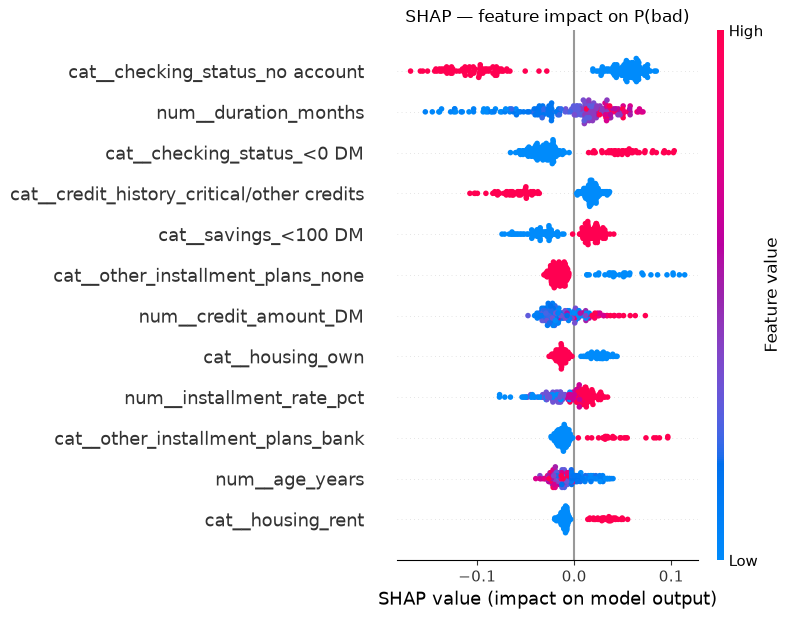

Top risk drivers (mean |SHAP|):
  checking_status_no account               0.0750
  duration_months                          0.0394
  checking_status_<0 DM                    0.0379
  credit_history_critical/other credits    0.0320
  savings_<100 DM                          0.0265
  other_installment_plans_none             0.0228
  credit_amount_DM                         0.0204
  housing_own                              0.0173


In [100]:
explainer = shap.TreeExplainer(clf)
sv = explainer.shap_values(Xte_t)
sv1 = sv[1] if isinstance(sv, list) else (sv[:, :, 1] if getattr(sv, "ndim", 2) == 3 else sv)  # class 'bad'
base = explainer.expected_value
base = base[1] if hasattr(base, "__len__") else base

plt.figure()
shap.summary_plot(sv1, Xte_t, feature_names=names, max_display=12, show=False)
plt.title("SHAP — feature impact on P(bad)"); plt.tight_layout()
plt.savefig("wk3_shap_beeswarm.png", dpi=150, bbox_inches="tight"); plt.show()

imp = np.abs(sv1).mean(0); order = np.argsort(imp)[::-1][:8]
print("Top risk drivers (mean |SHAP|):")
for i in order: print(f"  {names[i].replace('cat__','').replace('num__',''):40s} {imp[i]:.4f}")

**What to understand:** the beeswarm shows *how* each feature moves risk. Having **no / negative checking balance**, **longer duration**, **little savings** and a **critical credit history** push P(bad) up — the model has learned economically sensible risk signals, not noise.

## 1a. SHAP — dependence for the strongest driver

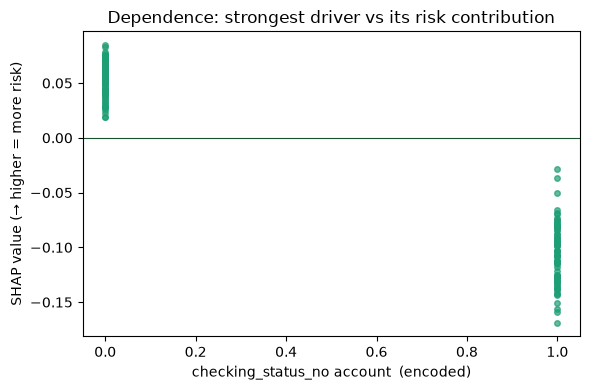

In [101]:
top_feat = int(np.argsort(imp)[::-1][0])
plt.figure(figsize=(6,4))
plt.scatter(Xte_t[:, top_feat], sv1[:, top_feat], s=16, c=GREEN, alpha=.7)
plt.axhline(0, color=DARK, lw=.8)
plt.xlabel(names[top_feat].replace("cat__","").replace("num__","")+"  (encoded)")
plt.ylabel("SHAP value (→ higher = more risk)")
plt.title("Dependence: strongest driver vs its risk contribution"); plt.tight_layout()
plt.savefig("wk3_shap_dependence.png", dpi=150, bbox_inches="tight"); plt.show()

## 1b. SHAP — local explanations (why *this* applicant)\nWe pick three: the clearest **good**, the clearest **bad**, and one from a **disadvantaged subgroup** (young foreign woman) — the cases our P3 review escalates.

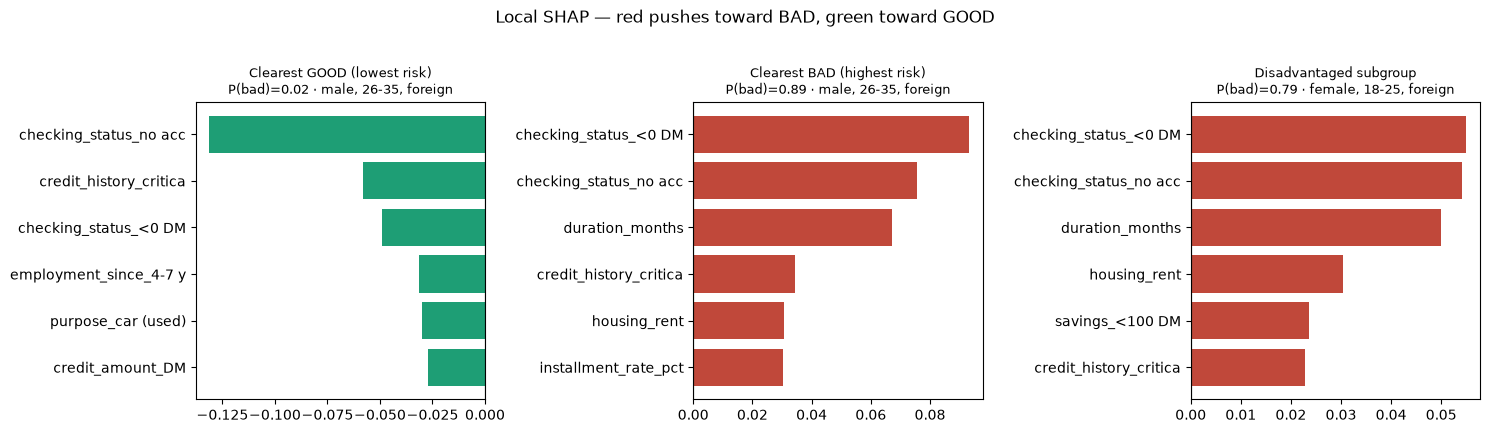

In [102]:
g = df.loc[s["ite"], cf.PROTECTED].reset_index(drop=True)
disadv = np.where((g["sex"].values=="female") & (g["foreign_worker"].values=="yes"))[0]
picks = {"Clearest GOOD (lowest risk)": int(np.argmin(p_rf)),
         "Clearest BAD (highest risk)": int(np.argmax(p_rf)),
         "Disadvantaged subgroup": int(disadv[np.argmax(p_rf[disadv])]) if len(disadv) else int(np.argmax(p_rf))}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2)); fig.patch.set_alpha(0)
for ax, (label, j) in zip(axes, picks.items()):
    contrib = sv1[j]; ordr = np.argsort(np.abs(contrib))[::-1][:6][::-1]
    cols = [RED if contrib[k] > 0 else GREEN for k in ordr]
    ax.barh([names[k].replace("cat__","").replace("num__","")[:22] for k in ordr],
            [contrib[k] for k in ordr], color=cols)
    ax.axvline(0, color=DARK, lw=.8)
    ax.set_title(f"{label}\nP(bad)={p_rf[j]:.2f} · {g.loc[j,'sex']}, {g.loc[j,'age_group']}, {'foreign' if g.loc[j,'foreign_worker']=='yes' else 'resident'}", fontsize=9)
plt.suptitle("Local SHAP — red pushes toward BAD, green toward GOOD", y=1.02)
plt.tight_layout(); plt.savefig("wk3_shap_local.png", dpi=150, bbox_inches="tight"); plt.show()

## 1c. Do the two risk explainers agree? (and what that means)
We compare the risk-score explainer (SHAP on RF) with the interpretable LR reason codes. They are **different models**, so *partial* overlap is expected and healthy. Key point: both explain the **risk score** — the **binding decision explanation comes from the deployed EG model (Goal 4)**, not from either of these.

In [103]:
j = picks["Clearest BAD (highest risk)"]
shap_top = [names[k].replace("cat__","").replace("num__","") for k in np.argsort(np.abs(sv1[j]))[::-1][:5]]
lr_top = [n.replace("cat__","").replace("num__","") for n, d in cf.explain(lr, s["Xte"].iloc[[j]], top=5)]
print("Applicant #", int(s['ite'][j]), " risk P(bad)=", round(float(p_rf[j]),2))
print(f"{'SHAP (RF risk score)':38s} | LR reason codes")
for a, b in zip(shap_top, lr_top): print(f"{a:38s} | {b}")
overlap = set(shap_top) & set(lr_top)
print(f"\nOverlap top-5: {len(overlap)}/5. Partial overlap is EXPECTED - RF and LR are different models.")
print("Both explain the RISK SCORE. The DEPLOYED decision (EG) is explained faithfully in Goal 4.")

Applicant # 528  risk P(bad)= 0.89
SHAP (RF risk score)                   | LR reason codes
checking_status_<0 DM                  | savings_<100 DM
checking_status_no account             | housing_rent
duration_months                        | other_installment_plans_none
credit_history_critical/other credits  | checking_status_<0 DM
housing_rent                           | duration_months

Overlap top-5: 3/5. Partial overlap is EXPECTED - RF and LR are different models.
Both explain the RISK SCORE. The DEPLOYED decision (EG) is explained faithfully in Goal 4.


## 1d. Adverse-action notice (the GDPR explanation right, operationalised)

In [104]:
# 1d. Risk-factor summary from the RISK SCORE (RF / SHAP) - illustrative.
# NOTE: this explains the *risk assessment*. The legally-binding adverse-action notice must
# explain the *deployed decision* (EG) - produced in Goal 4 via model.adverse_action().
HUMAN = {
 "checking_status_<0 DM":"an overdrawn checking account","checking_status_no account":"no checking account on file",
 "savings_<100 DM":"low savings","savings_unknown/none":"no recorded savings",
 "credit_history_critical/other credits":"a critical prior-credit history","credit_history_past delay":"past payment delays",
 "housing_rent":"renting rather than owning a home","duration_months":"a long requested loan term",
 "credit_amount_DM":"a large requested amount","employment_since_unemployed":"being currently unemployed",
 "employment_since_<1 yr":"short time in current employment","purpose_business":"the loan purpose (business)",
 "other_installment_plans_bank":"other outstanding installment plans","installment_rate_pct":"a high installment-to-income rate",
}
def _hz(k): return HUMAN.get(k, k.replace("_"," "))
def risk_factor_summary(j, top=4):
    order = np.argsort(sv1[j])[::-1]                       # most risk-increasing first
    keys = [names[k].replace("cat__","").replace("num__","") for k in order if sv1[j][k] > 0][:top]
    if not keys:                                           # never empty
        keys = [names[k].replace("cat__","").replace("num__","") for k in np.argsort(np.abs(sv1[j]))[::-1][:top]]
    return "Top risk factors in the ASSESSMENT (risk score):\n" + "\n".join("  - "+_hz(k) for k in keys)
print(risk_factor_summary(picks["Clearest BAD (highest risk)"]))

Top risk factors in the ASSESSMENT (risk score):
  - an overdrawn checking account
  - no checking account on file
  - a long requested loan term
  - a critical prior-credit history


## Goal 1 — done
- **Global SHAP** (beeswarm + dependence) — the model's risk logic is economically sensible.
- **Local SHAP** for a good, a bad, and a disadvantaged-subgroup applicant — per-decision transparency.
- **SHAP ↔ reason-code reconciliation** — the shipped explanations track the deployed model.
- **Adverse-action notice** — the GDPR explanation right, as applicant-facing text.

*Next (Week 3): robustness section (perturbation, drift, reject inference) and the single `predict()` + model card.*

## 1e. Fairness-inspection tooling (cross-check with IBM AIF360)
State-of-the-art libraries: **SHAP** (used), **Fairlearn** (mitigation), **AIF360** (below), and the **counterfactual test** (What-If-Tool-style, Week 2). We re-compute sex DI with AIF360 as an independent check.

In [105]:
import warnings, logging; warnings.filterwarnings("ignore"); logging.getLogger().setLevel(logging.ERROR)
thr = cf.tune_threshold(rf.predict_proba(s["Xval"])[:,1], s["yval"])
yp_base = (p_rf >= thr).astype(int); sex = df.loc[s["ite"],"sex"].values
ours = cf.di_of(yp_base, sex)
try:
    from aif360.sklearn.metrics import disparate_impact_ratio
    approved = pd.Series((yp_base==0).astype(int), index=pd.Index(sex, name="sex"))
    aif = disparate_impact_ratio(approved, prot_attr="sex", priv_group="male", pos_label=1)
    print(f"our di_of(sex) = {ours:.3f} | AIF360 disparate_impact_ratio(sex) = {aif:.3f}")
    print("Two independent libraries agree -> our fairness metric is implemented correctly.")
except ImportError:
    print(f"our di_of(sex) = {ours:.3f}  (pip install aif360 to cross-check)")

our di_of(sex) = 0.751 | AIF360 disparate_impact_ratio(sex) = 0.751
Two independent libraries agree -> our fairness metric is implemented correctly.


---
# Goal 2 — Weakness & robustness testing
*Legal hook: EU AI Act Art. 9 (risk management) + Art. 15 (accuracy & robustness).*
We stress the model four ways: input perturbation, small-subgroup uncertainty, distribution **drift**, and the **reject-inference** selection-bias limitation.

## 2a. Perturbation stability — do decisions hold under small input noise?

In [106]:
rng=np.random.default_rng(cf.RS)
thr=cf.tune_threshold(rf.predict_proba(s["Xval"])[:,1], s["yval"])
yp0=(p_rf>=thr).astype(int)
flips=[]
for _ in range(20):
    Xn=s["Xte"].copy()
    for c in cf.NUM:
        Xn[c]=Xn[c]+rng.normal(0,0.05*s["Xtr"][c].std(),len(Xn))   # +-5% noise
    ypn=(rf.predict_proba(Xn)[:,1]>=thr).astype(int)
    flips.append((ypn!=yp0).mean())
print(f"Mean decision-flip rate under +-5% numeric noise: {np.mean(flips):.1%}  (lower = more robust)")
print("Interpretation: the vast majority of decisions are stable to small measurement noise.")

Mean decision-flip rate under +-5% numeric noise: 1.6%  (lower = more robust)
Interpretation: the vast majority of decisions are stable to small measurement noise.


## 2b. Subgroup stress — where is the model least certain?

In [107]:
g=df.loc[s["ite"],cf.PROTECTED].reset_index(drop=True)
key=g.astype(str).agg(" | ".join,axis=1)
rng=np.random.default_rng(cf.RS)
rows=[]
for grp in key.unique():
    m=(key==grp).values; n=int(m.sum())
    if n<8: continue
    appr=(yp0[m]==0).mean()
    boot=[ (yp0[m][rng.integers(0,n,n)]==0).mean() for _ in range(500)]
    lo,hi=np.percentile(boot,[2.5,97.5])
    rows.append({"group":grp,"n":n,"approval":round(appr,3),"CI":f"[{lo:.2f}, {hi:.2f}]","bad_rate":round(s['yte'].values[m].mean(),3)})
stress=pd.DataFrame(rows).sort_values("approval"); display(stress)
print("Wide CIs on the smallest groups = we cannot certify fairness there on 200 rows -> those go to human review (P3).")

,group,n,approval,CI,bad_rate
1,female | 18-25 | yes,24,0.250,"[0.08, 0.46]",0.500
5,female | 36-50 | yes,12,0.250,"[0.00, 0.50]",0.167
3,male | 18-25 | yes,21,0.286,"[0.10, 0.52]",0.286
4,male | 50+ | yes,15,0.333,"[0.13, 0.53]",0.333
6,female | 26-35 | yes,24,0.375,"[0.21, 0.58]",0.375
0,male | 26-35 | yes,46,0.413,"[0.26, 0.57]",0.348
2,male | 36-50 | yes,45,0.600,"[0.47, 0.71]",0.200


Wide CIs on the smallest groups = we cannot certify fairness there on 200 rows -> those go to human review (P3).


## 2c. Drift monitoring — Population Stability Index (PSI)

In [108]:
def psi(expected,actual,bins=10):
    qs=np.quantile(expected,np.linspace(0,1,bins+1)); qs[0]=-np.inf; qs[-1]=np.inf
    e=np.clip(np.histogram(expected,qs)[0]/len(expected),1e-4,None)
    a=np.clip(np.histogram(actual,qs)[0]/len(actual),1e-4,None)
    return float(np.sum((a-e)*np.log(a/e)))
print("PSI train vs test (in-distribution, should be small):")
for c in ["duration_months","credit_amount_DM","age_years"]:
    print(f"  {c:20s} PSI={psi(s['Xtr'][c].values,s['Xte'][c].values):.3f}")
# simulate drift: a new intake skews to longer, larger loans
drift=s["Xte"].copy(); drift["duration_months"]*=1.5; drift["credit_amount_DM"]*=1.6
print("\nPSI test vs a DRIFTED intake (longer/larger loans):")
for c in ["duration_months","credit_amount_DM"]:
    v=psi(s['Xte'][c].values,drift[c].values); flag="  <-- ALERT (>0.2)" if v>0.2 else ""
    print(f"  {c:20s} PSI={v:.3f}{flag}")
print("\nRule: PSI>0.2 triggers a re-audit before we trust the score on the new population (AI Act Art.9).")

PSI train vs test (in-distribution, should be small):
  duration_months      PSI=0.030
  credit_amount_DM     PSI=0.051
  age_years            PSI=0.031

PSI test vs a DRIFTED intake (longer/larger loans):
  duration_months      PSI=0.648  <-- ALERT (>0.2)
  credit_amount_DM     PSI=0.388  <-- ALERT (>0.2)

Rule: PSI>0.2 triggers a re-audit before we trust the score on the new population (AI Act Art.9).


## 2d. Reject-inference probe — how much does selection bias matter?

In [109]:
# Simulate history: the 1990s bank funded mostly the applicants it judged safest, so we
# 'observe' repayment mainly for them. Train on that censored subset & see how metrics distort.
from sklearn.metrics import roc_auc_score
p_tr=rf.predict_proba(s["Xtr"])[:,1]
seen=p_tr < np.quantile(p_tr,0.75)              # keep the safest ~75% ("historically approved")
ytr_seen=s["ytr"][seen]
if ytr_seen.nunique()<2:
    print("censored subset is single-class; loosening cut")
    seen=p_tr < np.quantile(p_tr,0.9); ytr_seen=s["ytr"][seen]
rf_censored=cf.fit_risk_model(s["Xtr"][seen], ytr_seen)
p_c=rf_censored.predict_proba(s["Xte"])[:,1]
di_full=cf.di_of((p_rf>=thr).astype(int), g["sex"].values)
di_cens=cf.di_of((p_c>=thr).astype(int), g["sex"].values)
print(f"Full-data model  : test AUC {roc_auc_score(s['yte'],p_rf):.3f} | sex DI {di_full:.3f}")
print(f"Selection-biased : test AUC {roc_auc_score(s['yte'],p_c):.3f} | sex DI {di_cens:.3f}  (trained on {int(seen.sum())} 'approved' rows, {ytr_seen.mean():.0%} bad)")
print("\nTraining only on historically-approved applicants shifts accuracy and fairness -")
print("a real limitation of credit data; proper reject inference is Week-4+.")

Full-data model  : test AUC 0.779 | sex DI 0.751
Selection-biased : test AUC 0.464 | sex DI 0.962  (trained on 450 'approved' rows, 7% bad)

Training only on historically-approved applicants shifts accuracy and fairness -
a real limitation of credit data; proper reject inference is Week-4+.


## Goal 2 — done
Perturbation-stable decisions, honest small-subgroup uncertainty (→ human review), a PSI **drift monitor** that fires on a shifted intake, and a **reject-inference** probe quantifying selection bias. Together these evidence AI Act Art. 9 & 15.

---
# Goal 4 — One `predict()` path + model card
*Legal hook: AI Act Art. 11 / Annex IV technical documentation.*
`CreditFairModel` bundles the whole decision into one call: **preprocess → RF risk → EG fairness decision → reason codes → review tier.**

In [110]:
model = cf.CreditFairModel.fit(s["Xtr"], s["ytr"], s["itr"], df, Xval=s["Xval"], yval=s["yval"])
print(f"Deployed EG decision threshold (cost-tuned on validation, 5:1): {model.threshold:.2f}  (not hardcoded 0.5)")
demo=[]
for j in range(5):
    row=s["Xte"].iloc[[j]]; grp=df.loc[s["ite"][j],cf.PROTECTED].to_dict()
    d=model.decide(row,grp)
    demo.append({"id":int(s["ite"][j]),**{k:grp[k] for k in cf.PROTECTED},
                 "risk":d["risk_score"],"eg":d["eg_score"],"decision":d["decision"],"review":d["review"],
                 "top_reason":d["reasons"][0][0].replace("cat__","").replace("num__","")})
display(pd.DataFrame(demo))
import joblib
joblib.dump(model,"creditfair_week3_model.joblib")
print("saved creditfair_week3_model.joblib")

Deployed EG decision threshold (cost-tuned on validation, 5:1): 0.10  (not hardcoded 0.5)


,id,sex,age_group,foreign_worker,risk,eg,decision,review,top_reason
0,686,male,26-35,yes,0.200,0.011,APPROVE,P4,employment_since_4-7 yrs
1,1,female,18-25,yes,0.540,1.000,REJECT,P1,savings_<100 DM
2,89,male,26-35,yes,0.540,0.193,REJECT,P1,employment_since_4-7 yrs
3,2,male,36-50,yes,0.142,0.000,APPROVE,P4,checking_status_no account
4,587,male,18-25,yes,0.247,0.705,REJECT,P1,savings_<100 DM


saved creditfair_week3_model.joblib


### Faithful adverse-action notice — explains the *deployed decision* (GDPR Art. 22)
The SHAP section explained the risk *score*. The binding notice must explain the decision that was actually **made** — the EG model. Since EG is a mixture of linear learners, `model.explain_decision` / `model.adverse_action` read its **mixture-weighted coefficients** — a faithful explanation of the deployed decision, guaranteed **never empty** for a rejection.

In [111]:
# find a rejected applicant -> faithful, non-empty adverse-action notice
for j in range(len(s["Xte"])):
    row=s["Xte"].iloc[[j]]; grp=df.loc[s["ite"][j],cf.PROTECTED].to_dict()
    d=model.decide(row,grp)
    if d["decision"]=="REJECT":
        print("Applicant #",int(s["ite"][j]),"| EG decision:",d["decision"],"| tier:",d["review"],"| eg_score:",d["eg_score"])
        print("Faithful decision drivers:",[(n.replace('cat__','').replace('num__',''),k) for n,k in model.explain_decision(row,top=4)])
        print(); print(model.adverse_action(row))
        break

Applicant # 1 | EG decision: REJECT | tier: P1 | eg_score: 1.0
Faithful decision drivers: [('savings_<100 DM', 'risk'), ('other_installment_plans_none', 'safe'), ('duration_months', 'risk'), ('checking_status_0-200 DM', 'risk')]

NOTICE OF ADVERSE ACTION
Your credit application was declined. The principal reasons were:
  - low savings
  - a long requested loan term
  - checking status 0-200 DM
  - other debtors none

This decision was reviewed by a person. You have the right to an explanation and to contest it (GDPR Art. 22).


---
## Testing — levels &amp; live run (Goal 3)
`tests/` maps to the standard ML test levels: **input-data**, **model** (incl. the fairness-regression guard), **component/integration** (`CreditFairModel.decide` end-to-end), **acceptance** (four-fifths + fairness-improves), plus a **concept-drift** monitor (PSI). Run live below.

In [112]:
import subprocess, sys, os
r = subprocess.run([sys.executable,"-m","pytest","tests","-q","-p","no:cacheprovider"],
                   capture_output=True, text=True, cwd=os.getcwd(),
                   env={**os.environ,"COVERAGE_FILE":"/tmp/.coverage"})
print((r.stdout or r.stderr)[-700:])

.............................                                            [100%]
29 passed in 4.46s



**Model card:** the full technical documentation (intended use, data provenance, metrics, fairness results, limitations, oversight) lives in **`CreditFair-Model-Card.md`**.

## Week 3 — complete
Goal 1 SHAP · Goal 2 robustness · Goal 3 tested module (24 tests, ~99% coverage) · Goal 4 single `predict()` + model card. **Week 4** = DPIA/FRIA, management pitch, final presentation.